<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">


# Train-Test Split and Cross-Validation Lab 


## Review of Train/Test Validation Methods

We've discussed overfitting, underfitting, and how to validate the "generalizeability" of your models by testing them on unseen data. 

In this lab you'll practice two related validation methods: 
1. **train/test split**
2. **k-fold cross-validation**

Train/test split and k-fold cross-validation both serve two useful purposes:
- We prevent overfitting by not using all the data, and
- We retain some remaining data to evaluate our model.

In the case of cross-validation, the model fitting and evaluation is performed multiple times on different train/test splits of the data.

Ultimately we can use the training/test validation framework to compare multiple models on the same dataset. This could be comparisons of two linear models, or of completely different models on the same data.


## Instructions

For your independent practice, fit **three different models** on the Boston Housing Data. For example, you could pick three different subsets of variables, one or more polynomial models, or any other model that you like. 

**Start with train/test split validation:**
* Fix a testing/training split of the data.
* Train each of your models on the training data.
* Evaluate each of the models on the testing data.
* Rank the models by how well they score on the testing data set.

**Then try k-fold cross-validation:**
* Perform a k-fold cross-validation and use the cross-validation scores to compare your models. Did this change your rankings?
* Try a few different k-splits of the data for the same models.

If you're interested, try a variety of response variables. We start with **PRICE** (the `.target` attribute from the data set load method).

In [1]:
from matplotlib import pyplot as plt

import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score

from sklearn import datasets

# %config InlineBackend.figure_format = 'retina'
# %matplotlib inline

# plt.style.use('fivethirtyeight')


In [2]:
# Load the Boston Housing dataset
boston_h = pd.read_csv('./BostonHousing2.csv')


In [3]:
# No code here please


In [4]:
# your code here
# what is the shape of the dataframe?
boston_h.shape


(506, 14)

In [5]:
# No code here please

### 1) Clean up any data problems.

Fix any problems with the data, if applicable.

In [6]:
# your code here
# any missing data?
boston_h.isnull().sum()


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [7]:
# No code here please

# There is no missing data as per the result

In [8]:
# your code here
# Get overview of your data

boston_h.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [9]:
# No code here please



In [10]:
# your code here
# Get the max for each column
boston_h.max()


CRIM        88.9762
ZN         100.0000
INDUS       27.7400
CHAS         1.0000
NOX          0.8710
RM           8.7800
AGE        100.0000
DIS         12.1265
RAD         24.0000
TAX        711.0000
PTRATIO     22.0000
B          396.9000
LSTAT       37.9700
PRICE       50.0000
dtype: float64

In [11]:
# No code here please


In [12]:
# your code here
# Get the min for each column
boston_h.min()


CRIM         0.00632
ZN           0.00000
INDUS        0.46000
CHAS         0.00000
NOX          0.38500
RM           3.56100
AGE          2.90000
DIS          1.12960
RAD          1.00000
TAX        187.00000
PTRATIO     12.60000
B            0.32000
LSTAT        1.73000
PRICE        5.00000
dtype: float64

In [13]:
# No code here please


### 2) Select 3–4 variables with your data set on which to perform a 50-50 train/test split.

- Use scikit-learn.
- Score and plot your predictions.

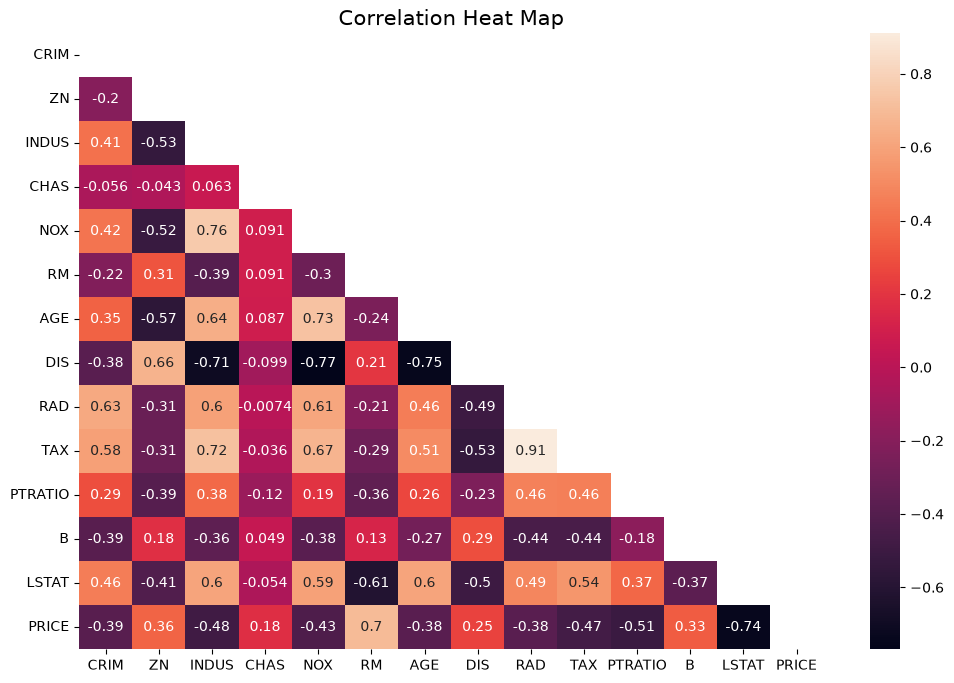

In [14]:
# your code here
# get correlation in corr and do a coorelation heatmap.
plt.figure(figsize=(12,8))
plt.title('Correlation Heat Map',size=15)
sns.heatmap(boston_h.corr(numeric_only = True), annot = True, mask = np.triu(boston_h.corr()));
plt.yticks(rotation = 0);

In [15]:
# No code here please



 Separate `RM, LSTAT ,INDUS` into X.

In [16]:
# your code here
X = boston_h[['RM','LSTAT','INDUS']]


# display head of X
X.head()

,RM,LSTAT,INDUS
0,6.575,4.98,2.31
1,6.421,9.14,7.07
2,7.185,4.03,7.07
3,6.998,2.94,2.18
4,7.147,5.33,2.18


In [17]:
# No code here please


- Set the target y to be the column PRICE

In [18]:
# set the target
y = boston_h['PRICE']
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64

In [19]:
# No code here please


#### split the data using train_test_split, start with 50-50 split.
Also try different parameters. <shift+tab> for doc string 

In [20]:
# your code here
#perform a 50-50 train/test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.50,random_state=1)




In [21]:
# check the shape of your train and test sets!
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(253, 3) (253,)
(253, 3) (253,)


In [22]:
# No code here please



In [23]:
# Instantiate model, call it slr
slr = LinearRegression()
# fit the instance on train set
slr.fit(X_train, y_train)

# get predictions and add as a new column 'PRICE_predict' into your dataframe
y_pred=slr.predict(X)
boston_h['PRICE_predict']=slr.predict(X)


# print the train and test scores
print(f'Scores for the train: {slr.score(X_train,y_train)}')
print(f'Scores for the test: {slr.score(X_test,y_test)}')

# Add 'residual' column into your dataframe. Calculate it manually
boston_h['residual'] = y - boston_h['PRICE_predict']


Scores for the train: 0.6444167000808319
Scores for the test: 0.6259965956483379


In [24]:
boston_h.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE,PRICE_predict,residual
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,29.497348,-5.497348
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,25.834846,-4.234846
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,32.131382,2.568618
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,32.552968,0.847032
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,31.860942,4.339058


In [20]:
# NO CODE HERE

boston_h.head(5)   # notice the 'PRICE_predict' and 'residual'  columns


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE,PRICE_predict,residual
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,29.497348,-5.497348
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,25.834846,-4.234846
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,32.131382,2.568618
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,32.552968,0.847032
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,31.860942,4.339058


### 3) Repeat the above process with 70-30 and 90-10 splits.

- Score and plot.  
- What do you learn?

In [28]:
# with 70 - 30 split (start your namings with X2 and y2)
X2_train, X2_test, y2_train, y2_test = train_test_split(X,y,test_size = 0.3,random_state=1)


In [30]:
# check the shape of training and testing for both X and y
print(X2_train.shape, y2_train.shape)
print(X2_test.shape, y2_test.shape)

(354, 3) (354,)
(152, 3) (152,)


In [22]:
# NO CODE HERE



(354, 3) (354,)
(152, 3) (152,)


In [31]:
# Instantiate model, call it slr2
slr2 = LinearRegression()
# fit the instance on train set
slr2.fit(X2_train, y2_train)

# get predictions and add as a new column 'PRICE_predict2' into your dataframe
y_pred2=slr2.predict(X)
boston_h['PRICE_predict2']=slr2.predict(X)




# get the train and test scores
print(f'Scores for the 2nd train: {slr2.score(X2_train,y2_train)}')
print(f'Scores for the 2nd test: {slr2.score(X2_test,y2_test)}')


Scores for the 2nd train: 0.6114110572311812
Scores for the 2nd test: 0.6856631640613768


In [32]:
# Do 90 - 10 split (start your namings with X3 and y3)
X3_train, X3_test, y3_train, y3_test = train_test_split(X,y,test_size = 0.1,random_state=1)


In [33]:
# check the shape of your train and test sets!
print(X3_train.shape, y3_train.shape)
print(X3_test.shape, y3_test.shape)


(455, 3) (455,)
(51, 3) (51,)


In [25]:
# NO CODE HERE PLEASE



(455, 3) (455,)
(51, 3) (51,)


In [34]:
# your code here
# Instantiate model, call it slr3
slr3 = LinearRegression()
# fit the instance on train set
slr3.fit(X3_train, y3_train)

# get predictions and add as a new column 'PRICE_predict3' into your dataframe
y_pred3=slr3.predict(X)
boston_h['PRICE_predict3']=slr3.predict(X)




# get the train and test scores
print(f'Scores for the 3rd train: {slr3.score(X3_train,y3_train)}')
print(f'Scores for the 3rd test: {slr3.score(X3_test,y3_test)}')


Scores for the 3rd train: 0.6337726546654995
Scores for the 3rd test: 0.6854817797677493


In [37]:
# your code here
# print the score for each model for both training and testing
print(f' Scores for 70-30 of the training is: {slr2.score(X2_train,y2_train)}')
print(f' Scores for 70-30 of the testing is: {slr2.score(X2_test,y2_test)}')
print(f' Scores for 90-10 of the training is: {slr3.score(X3_train,y3_train)}')
print(f' Scores for 90-10 of the testing is: {slr3.score(X3_test,y3_test)}')

 Scores for 70-30 of the training is: 0.6114110572311812
 Scores for 70-30 of the testing is: 0.6856631640613768
 Scores for 90-10 of the training is: 0.6337726546654995
 Scores for 90-10 of the testing is: 0.6854817797677493


In [27]:
# NO CODE HERE PLEASE
# Note: your result may be different than the below result





Score for 50-50 training is: 0.6444167000808319
Score for 50-50 test is: 0.625996595648338

 Score for 70-30 training is: 0.6114110572311812
Score for 70-30 test is: 0.6856631640613768

 Score for 90-10 training is: 0.6337726546654995
Score for 90-10 test is: 0.6854817797677495


### 4) Try k-folds cross-validation with k between 5–10 for your regression. 

- What seems optimal? 
- How do your scores change?  
- Try out different folds to get a sense of how this impacts your score.


In [51]:
# your code here
# Perform 5-19 fold cross validation and print the scores mean of each fold
# Hint: use for loop with range
i=5
while i <= 19:
    scores_shuffle=cross_val_score(slr, X_train, y_train, cv=i)
    print(f'{i} -fold Mean cross validation scores: {scores_shuffle.mean()}')
    i=i+1

5 -fold Mean cross validation scores: 0.612292364088262
6 -fold Mean cross validation scores: 0.605252781317937
7 -fold Mean cross validation scores: 0.6174728605039695
8 -fold Mean cross validation scores: 0.6096594586907604
9 -fold Mean cross validation scores: 0.5805812634394933
10 -fold Mean cross validation scores: 0.5787758400458259
11 -fold Mean cross validation scores: 0.5742524955376684
12 -fold Mean cross validation scores: 0.5752279253493318
13 -fold Mean cross validation scores: 0.5828120641886376
14 -fold Mean cross validation scores: 0.5908039180479218
15 -fold Mean cross validation scores: 0.5791655649116473
16 -fold Mean cross validation scores: 0.5587094558821805
17 -fold Mean cross validation scores: 0.5080571727286629
18 -fold Mean cross validation scores: 0.5071500066902846
19 -fold Mean cross validation scores: 0.5803611337747899


In [29]:
# NO CODE HERE PLEASE







5 -fold Mean Cross-validated scores: 0.2721623765094543
6 -fold Mean Cross-validated scores: 0.3142345373463616
7 -fold Mean Cross-validated scores: 0.2895542157978465
8 -fold Mean Cross-validated scores: 0.18788747298812644
9 -fold Mean Cross-validated scores: 0.21267866140500172
10 -fold Mean Cross-validated scores: -0.05984279424821346
11 -fold Mean Cross-validated scores: -0.07288640345001852
12 -fold Mean Cross-validated scores: 0.05185877964074329
13 -fold Mean Cross-validated scores: -0.06182032758529849
14 -fold Mean Cross-validated scores: 0.11521124489362965
15 -fold Mean Cross-validated scores: -0.12625725572815108
16 -fold Mean Cross-validated scores: 0.06538043865224169
17 -fold Mean Cross-validated scores: -0.058071075140162826
18 -fold Mean Cross-validated scores: -0.08545435276537733
19 -fold Mean Cross-validated scores: -0.08492104740877611


In [52]:
# your code here
# Perform 5-19 fold cross validation
# use KFold to shuffle the data - does the result changes?
i=5
while i <= 19:
    kf=KFold(n_splits= i, shuffle=True, random_state=42)
    scores_shuffle=cross_val_score(slr, X_train, y_train, cv=kf)
    print(f'{i} -fold Mean cross validation scores: {scores_shuffle.mean()}')
    i=i+1



5 -fold Mean cross validation scores: 0.6109947886711187
6 -fold Mean cross validation scores: 0.6252985382218904
7 -fold Mean cross validation scores: 0.6076806744403648
8 -fold Mean cross validation scores: 0.6365952316162717
9 -fold Mean cross validation scores: 0.6241527329311438
10 -fold Mean cross validation scores: 0.6076888168353228
11 -fold Mean cross validation scores: 0.6172670560045991
12 -fold Mean cross validation scores: 0.6214201831833245
13 -fold Mean cross validation scores: 0.5888247912301422
14 -fold Mean cross validation scores: 0.6078392950794724
15 -fold Mean cross validation scores: 0.6048044375239238
16 -fold Mean cross validation scores: 0.5940539355803984
17 -fold Mean cross validation scores: 0.5976420941704235
18 -fold Mean cross validation scores: 0.6091496080825554
19 -fold Mean cross validation scores: 0.5628145678626659


In [30]:
# NO CODE HERE PLEASE





5 -fold Mean Cross-validated scores: 0.6279248609998469
6 -fold Mean Cross-validated scores: 0.6218923877181085
7 -fold Mean Cross-validated scores: 0.6094497041637349
8 -fold Mean Cross-validated scores: 0.6139184661257469
9 -fold Mean Cross-validated scores: 0.5992558002615535
10 -fold Mean Cross-validated scores: 0.6234837355036905
11 -fold Mean Cross-validated scores: 0.6041012269944382
12 -fold Mean Cross-validated scores: 0.6103682865047042
13 -fold Mean Cross-validated scores: 0.5987598877274162
14 -fold Mean Cross-validated scores: 0.6165867056848183
15 -fold Mean Cross-validated scores: 0.6039985922213842
16 -fold Mean Cross-validated scores: 0.6088238803503652
17 -fold Mean Cross-validated scores: 0.5891289453486923
18 -fold Mean Cross-validated scores: 0.5822342074551123
19 -fold Mean Cross-validated scores: 0.6011241925008676


#### does the result changes after shuffle?

> your answer here : 
 Yes the results changes siginificantly after shhuffling, with the standard cross_val_score the cv score goes down as the folds increase and thats because the dataset is ordered in a way that influences it. Without shuffling, certain rows placed into test folds create bais splits, leading to underperformance. With the shuffling, the dataset order is randomized across the folds, ensuring every training and validation fold gets a balanced, unbiased representation of the overall dataset.
